Import and Install

In [ ]:
!apt-get -qq install -y libsm6 libxext6 && pip install -q -U opencv-python
!pip install Pillow
!pip install kmeans-pytorch
!git clone https://github.com/bernardo-martins/color_recognition.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 MB 6.7 MB/s eta 0:00:00
Cloning into 'color_recognition'...
remote: Enumerating objects: 98, done.
remote: Total 98 (delta 0), reused 0 (delta 0), pack-reused 98
Receiving objects: 100% (98/98), 59.25 KiB | 1.35 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
import pandas as pd
import os
from PIL import Image
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
from kmeans_pytorch import kmeans
from sklearn.cluster import KMeans
import torch
import numpy as np
from collections import Counter
import random

Functions

In [ ]:
def getRandomImage(images):
    if(len(images) == 0):
      return -1
    return random.choice(images)

def RGB2HEX(color):
    return "#{:02x}{:02x}{:02x}".format(int(color[0]), int(color[1]), int(color[2]))

To Run

In [ ]:
image_directory = './color_recognition/'
image_files = [f for f in os.listdir(image_directory) if f.endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp'))]
images = []

data_size, dims, num_clusters = 1000, 2, 3
x = np.random.randn(data_size, dims) / 6
x = torch.from_numpy(x)

reading:  ./color_recognition/0c8ceef0-b77a-4bdb-8969-e6563322eac9.png


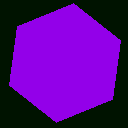

reading:  ./color_recognition/0cbc7316-253e-4229-a724-3921c88d64fa.png


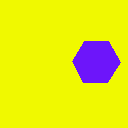

reading:  ./color_recognition/0b8c15cc-c7a4-44bc-8a62-8348989632ae.png


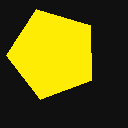

reading:  ./color_recognition/0ad57b66-08f9-4375-889a-11abd6844a59.png


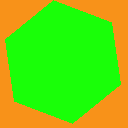

reading:  ./color_recognition/0ccd936b-89bd-4263-a03d-f524eade886d.png


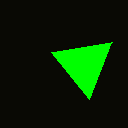

reading:  ./color_recognition/0c6118d4-fc7a-4170-ba28-d7413fd65e2f.png


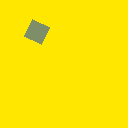

reading:  ./color_recognition/0c4f2bae-55d2-459e-b725-cadb2ee4f2b0.png


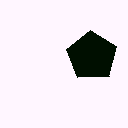

reading:  ./color_recognition/0a4aa824-0a3e-4956-9ea2-092247c7ba4d.png


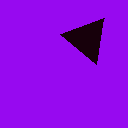

reading:  ./color_recognition/0cc335f1-a029-4207-b1a2-5190987468c7.png


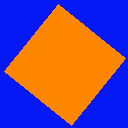

reading:  ./color_recognition/0cc9e21a-b753-4d82-b5eb-63465a592f92.png


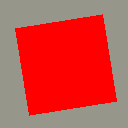

reading:  ./color_recognition/0be6f556-0f01-4191-98ff-4cb0d0b98b3e.png


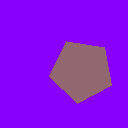

reading:  ./color_recognition/0c467463-5e42-4351-9958-e6fc1c6e685e.png


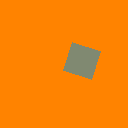

reading:  ./color_recognition/0b81c150-081f-4752-8683-3ad738c5530b.png


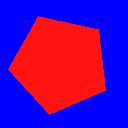

reading:  ./color_recognition/0b611296-9d92-480d-8db8-697694db4c5e.png


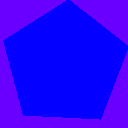

reading:  ./color_recognition/00b319c9-ad5b-4ed8-9c46-c68e6655b8d8.png


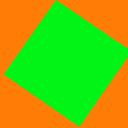

reading:  ./color_recognition/0b3b1d9c-45be-4612-80a8-d1b4f48d490f.png


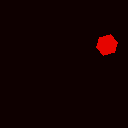

reading:  ./color_recognition/0ca542e4-7e38-47ee-bb72-56df3e0ec0cc.png


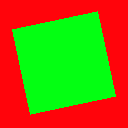

reading:  ./color_recognition/0cb996e2-dc3f-47a9-be34-f8516fb22636.png


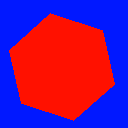

reading:  ./color_recognition/0b4e99ed-0531-4882-8aac-b27d4554fa5c.png


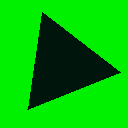

reading:  ./color_recognition/0ae51ebd-a17b-4ceb-b49e-54777dff2f53.png


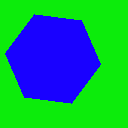

reading:  ./color_recognition/00cc3b55-46dd-4756-9d8a-60e311e5e62d.png


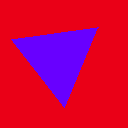

reading:  ./color_recognition/0c654736-6b84-4a40-bd2b-1ddb69b1a4e6.png


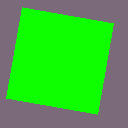

reading:  ./color_recognition/0b652b32-8678-4979-9714-4f0ea433343a.png


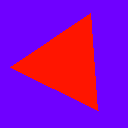

reading:  ./color_recognition/0c37062e-53cf-4fb3-ac9f-b56d9d40267d.png


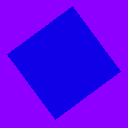

reading:  ./color_recognition/0cd32340-45d9-4a83-8cdb-27937a76cff1.png


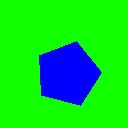

reading:  ./color_recognition/0a2b53c5-b53b-42ba-b757-8b454ecf7a62.png


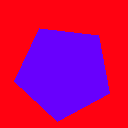

reading:  ./color_recognition/0c6bf611-bdcf-4dd3-bc02-d63d28a841db.png


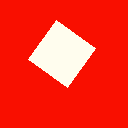

reading:  ./color_recognition/0b3e3d88-5e50-4b18-a93f-73955612faee.png


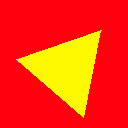

reading:  ./color_recognition/0c77c1f8-f55c-40c9-8d84-911ab4dd20f2.png


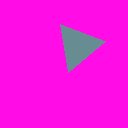

reading:  ./color_recognition/00b2be8a-30f3-4b24-8e8d-313e398e60ab.png


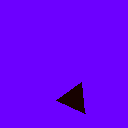

reading:  ./color_recognition/00cc1024-5f26-41db-81f3-6cd5c70d2523.png


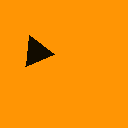

reading:  ./color_recognition/0bcabeec-25fa-4531-8b23-3ce3a90bf69a.png


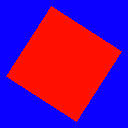

reading:  ./color_recognition/0c94339c-2ec0-4474-b7dc-464d13ddd1d6.png


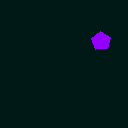

reading:  ./color_recognition/0c76f2ca-dd25-453a-b26a-6144e7f9e6b0.png


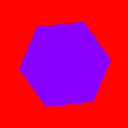

reading:  ./color_recognition/0b0e7520-90e5-4ccc-836e-29a0ceeae896.png


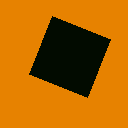

reading:  ./color_recognition/0c612ffd-d0f5-4fbf-82d3-48f36ec792c9.png


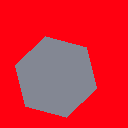

reading:  ./color_recognition/0c239528-4608-4949-a28c-d44f2fa91a0f.png


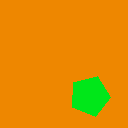

reading:  ./color_recognition/0c49dbcf-742e-4e63-a3f3-cf5db1cb890e.png


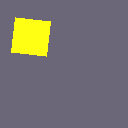

reading:  ./color_recognition/0c98fc04-cad9-426c-86e4-e5c198625c6e.png


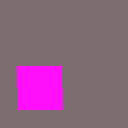

reading:  ./color_recognition/0ce60990-62cb-4708-8576-c8192d4edf7c.png


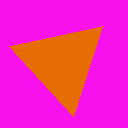

reading:  ./color_recognition/0bb36f81-a1d8-4b81-b50d-6263ba2bd15e.png


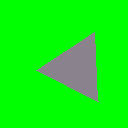

reading:  ./color_recognition/0c94812c-6900-4449-a56f-cc1eb36b3810.png


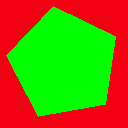

reading:  ./color_recognition/0b69351f-9525-4a02-a4bc-d84bdec0ed97.png


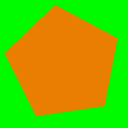

reading:  ./color_recognition/0bf14676-c358-42cb-967e-bc051d882f8e.png


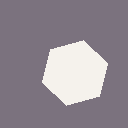

reading:  ./color_recognition/00a0e383-60b0-428a-af1d-fd252faefb1d.png


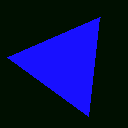

reading:  ./color_recognition/0c1455a4-c00b-4162-a5d7-a11ae879f1ea.png


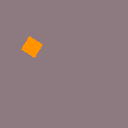

reading:  ./color_recognition/0b565cd4-e8b2-44ad-bfcf-8a77f6ec97b4.png


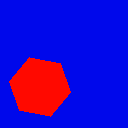

reading:  ./color_recognition/0a0e1617-c0e6-4b45-a8e6-ec0c746e2b7b.png


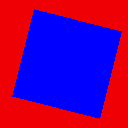

reading:  ./color_recognition/0cc89817-e5b7-4305-81ea-c42285f5f37b.png


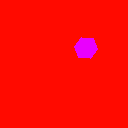

reading:  ./color_recognition/0c700cfd-bf1f-48aa-8045-3c25b9a1b6cf.png


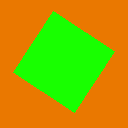

reading:  ./color_recognition/0b622061-593e-49cc-909b-3e22488004d9.png


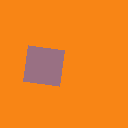

reading:  ./color_recognition/0bc32997-5176-46a5-bdb5-b3363bc9cfd6.png


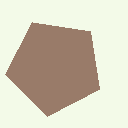

reading:  ./color_recognition/0b700881-3c12-4b4e-980b-81c4dced58a0.png


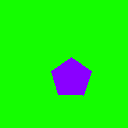

reading:  ./color_recognition/0b347da3-5989-4572-8ebd-1c55a8b4dbe9.png


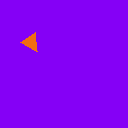

reading:  ./color_recognition/0ca782e1-0aa0-4a92-88bb-5a93b73bcc58.png


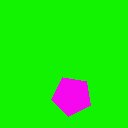

reading:  ./color_recognition/0b223948-9d5f-43df-99ae-07c342e38be8.png


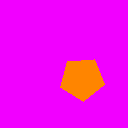

reading:  ./color_recognition/0c944d54-d0df-4044-85e1-0cad56c613ff.png


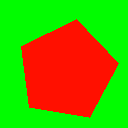

reading:  ./color_recognition/0b393258-cf1c-4f53-a64a-1ced55213c91.png


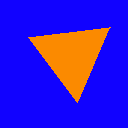

reading:  ./color_recognition/0be3a7b3-161a-4039-8787-19b77de392a3.png


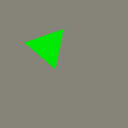

reading:  ./color_recognition/0c1c65bd-386c-4e06-84c2-8f13c4defab4.png


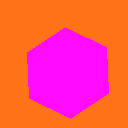

reading:  ./color_recognition/0bbc29f4-7a82-4b3f-a264-a3c23042a8f3.png


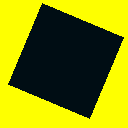

reading:  ./color_recognition/0bc0c4a4-97b9-4f1b-b172-cbb1a66b3e10.png


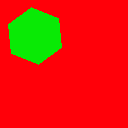

reading:  ./color_recognition/0c3246f2-8b18-4664-afd0-cc3ac5d14674.png


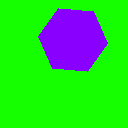

reading:  ./color_recognition/00c49faa-458a-49b5-b5f9-8342b91ee944.png


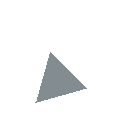

reading:  ./color_recognition/0cbc86d1-710e-44a2-b9ca-e462ca395676.png


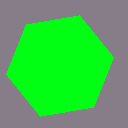

reading:  ./color_recognition/0b2c54c7-e059-49fb-b3da-4779c3f517fd.png


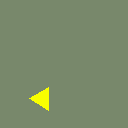

reading:  ./color_recognition/0c726b2a-6883-4ab5-aa4b-1d07dcda73c1.png


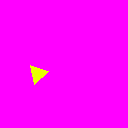

reading:  ./color_recognition/0c632d7e-3c92-45ee-83a7-6af142245cba.png


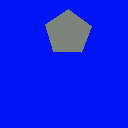

reading:  ./color_recognition/0be78bb4-206d-44b0-8639-4d2ca5903753.png


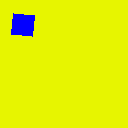

reading:  ./color_recognition/0af4b36c-6470-4b6e-acb2-65863772ae2a.png


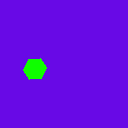

reading:  ./color_recognition/0ce62a21-6db8-4a57-894b-46efb15d9365.png


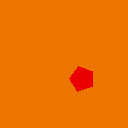

reading:  ./color_recognition/0ce45cc8-19c2-4004-a819-298a5602ba83.png


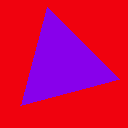

reading:  ./color_recognition/0cc80ce8-9aed-4125-958d-d931d59b5368.png


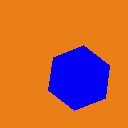

reading:  ./color_recognition/0ce9e16a-bc8e-4c95-81be-0afb73828377.png


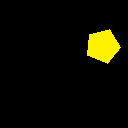

reading:  ./color_recognition/0a2d6d91-4104-40c2-87d3-3c7a04930000.png


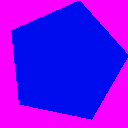

reading:  ./color_recognition/0ca9c2bc-dbc1-4bfe-b90e-6a4aefb42dfd.png


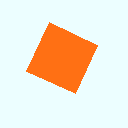

reading:  ./color_recognition/0accb1e2-4b80-43c3-adb5-275008ec490b.png


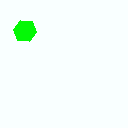

reading:  ./color_recognition/0c565d53-176f-4fe6-8239-64528a9d26e3.png


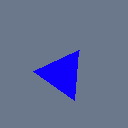

reading:  ./color_recognition/0ce4878b-4f3e-4984-b434-1a2092ef7516.png


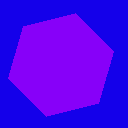

reading:  ./color_recognition/0b68c4eb-71bc-48d1-8759-13d8bc7aa398.png


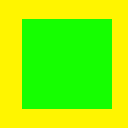

reading:  ./color_recognition/0b96017d-c4f5-46b2-bbff-87992ad6eba1.png


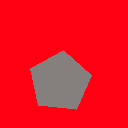

reading:  ./color_recognition/0b8c6e2f-31f9-4dd7-94d8-20b487b3d9c0.png


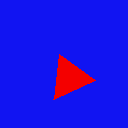

reading:  ./color_recognition/0adba5e5-9f4b-4b82-9454-09ee501c6800.png


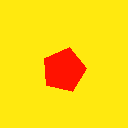

reading:  ./color_recognition/0b2b9212-7754-4e81-908b-43d61890f8c9.png


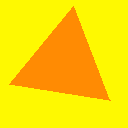

reading:  ./color_recognition/0c1c1425-bf18-4e87-9e3a-334e81f9a471.png


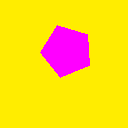

reading:  ./color_recognition/0b6b24ec-8126-4987-b780-e54027a4d841.png


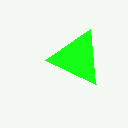

reading:  ./color_recognition/0c2e6852-0cc0-4972-8905-e3a31e1ec3ea.png


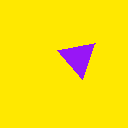

reading:  ./color_recognition/0c6a2320-d7bd-493a-a555-027d5bc3c0ce.png


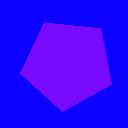

reading:  ./color_recognition/0a4d89eb-f895-4857-991c-c62edd8a4c7f.png


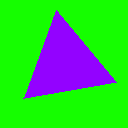

reading:  ./color_recognition/0b959789-7525-4dea-a7b7-1b5601091802.png


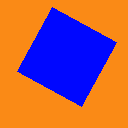

reading:  ./color_recognition/0cc5a0c2-6a9c-46a0-bbc1-c33bc667cd40.png


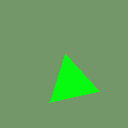

reading:  ./color_recognition/0bd9c286-7b14-4db3-b1c1-9e86bafcb381.png


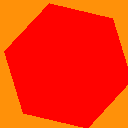

reading:  ./color_recognition/0af6e2fe-77f6-41a1-b9d3-d027f2ef8679.png


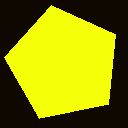

reading:  ./color_recognition/00cb8c6a-b001-400f-b0d3-22bda398f232.png


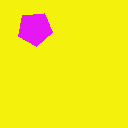

reading:  ./color_recognition/0b45c06a-8e35-4b68-89cc-3334b49a776d.png


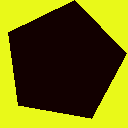

reading:  ./color_recognition/0c1627f8-48a8-411f-a164-479771319794.png


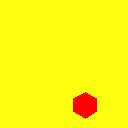

In [ ]:
#Read images from dir
for image_file in image_files:
    # Full path to the image file
    image_path = image_directory + image_file
    print('reading: ', image_path)
    image_path = os.path.join(image_directory, image_file)
    last_image = cv2.imread(image_path)
    #last_image = cv2.cvtColor(last_image, cv2.COLOR_BGR2RGB)
    images.append(last_image)
    window_name = 'Image'
    cv2_imshow(last_image)

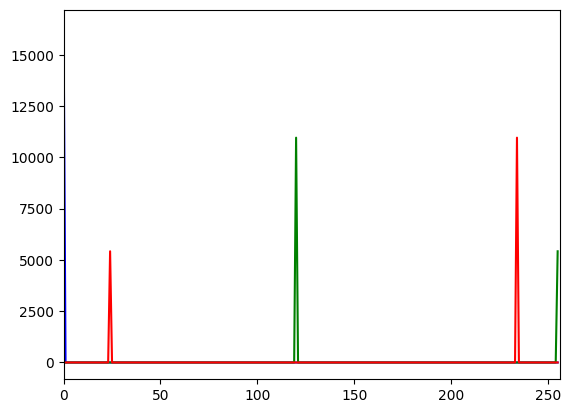

In [ ]:
#image = last_image
image = getRandomImage(images)
color = ('b','g','r')
for i,col in enumerate(color):
    histr = cv2.calcHist([image],[i],None,[256],[0,256])
    plt.plot(histr, color = col)
    plt.xlim([0,256])
plt.show()

In [ ]:
number_of_colors = 2
modified_image = image.reshape(image.shape[0]*image.shape[1], 3)
clf = KMeans(n_clusters = number_of_colors)
labels = clf.fit_predict(modified_image)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [ ]:
counts = Counter(labels)

centroids = clf.cluster_centers_
# We get ordered colors by iterating through the keys
ordered_colors = [centroids[i] for i in counts.keys()]
hex_colors = [RGB2HEX(ordered_colors[i]) for i in counts.keys()]
rgb_colors = [ordered_colors[i] for i in counts.keys()]

([<matplotlib.patches.Wedge at 0x78591011d240>,
 [Text(-0.5571690779158885, 0.9484527498058924, '#0078ea'),
  Text(0.5571690779158884, -0.9484527498058924, '#00ff18')])

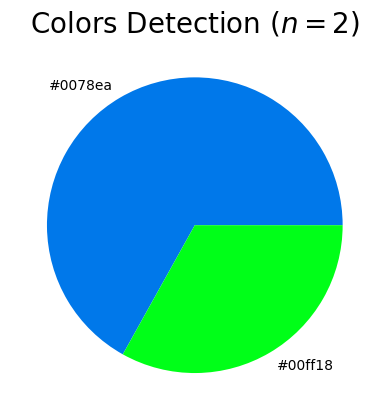

In [ ]:
plt.title('Colors Detection ($n=2$)', fontsize=20)
plt.pie(counts.values(), labels = hex_colors, colors = hex_colors)

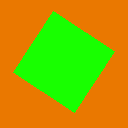

In [ ]:
cv2_imshow(image)

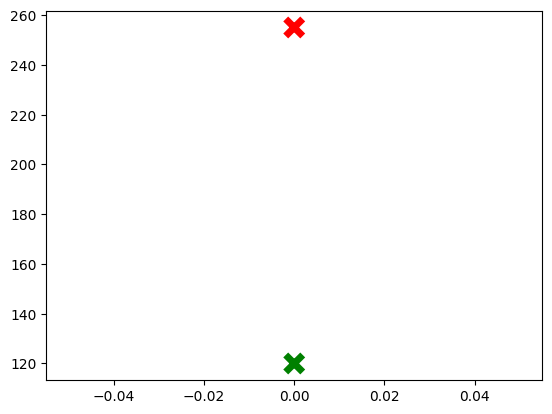

In [ ]:
centroids_x = centroids[:,0]
centroids_y = centroids[:,1]

plt.scatter(centroids_x,centroids_y,marker = "x", s=150,linewidths = 5, zorder = 10, c=['green', 'red'])